In [17]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.nn as nn

In [18]:
os.getcwd()

'd:\\work\\WBC_Segmentation\\WhileBloodCellClassification'

In [19]:
os.chdir("..")

In [20]:
os.getcwd()

'd:\\work\\WBC_Segmentation'

In [47]:
from WhiteBloodCellClassification.DomainAdaptation.DA_module import DomainAdaptationModule


trained_model_1 = DomainAdaptationModule()
trained_model_2 = DomainAdaptationModule()
trained_model_3 = DomainAdaptationModule()
trained_model_4 = DomainAdaptationModule()
path_model_1 = "D:\work\WBC_Segmentation\WhileBloodCellClassification\logs\exp_20260403_002152\model_epoch_0.pth"
path_model_2 = "D:\work\WBC_Segmentation\WhileBloodCellClassification\logs\exp_20260403_002152\model_epoch_20.pth"
path_model_3 = "D:\work\WBC_Segmentation\WhileBloodCellClassification\logs\exp_20260403_002152\model_epoch_10.pth"
path_model_4 = "D:\work\WBC_Segmentation\WhileBloodCellClassification\logs\exp_20260402_085430\model_epoch_15.pth"


trained_model_1.load_state_dict(torch.load(path_model_1, map_location="cpu"))
trained_model_1.eval()


trained_model_2.load_state_dict(torch.load(path_model_2, map_location="cpu"))
trained_model_2.eval()


trained_model_3.load_state_dict(torch.load(path_model_3, map_location="cpu"))
trained_model_3.eval()


trained_model_4.load_state_dict(torch.load(path_model_4, map_location="cpu"))
trained_model_4.eval()




DomainAdaptationModule(
  (pixel_encoder): PixelEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsamp

In [22]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

In [23]:
class JSTCDataset(Dataset):
    def __init__(self,root_dir,mask_dir,transform):
        self.mask_dir = os.path.join(root_dir, mask_dir)
        self.transform = transform


        self.images = sorted([f for f in os.listdir(self.mask_dir) if f.endswith('.bmp')])
        self.mask = sorted([f for f in os.listdir(self.mask_dir) if f.endswith('.png')])
    
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img_name = self.images[idx]
        mask_name = self.mask[idx]
        img_path = os.path.join(self.mask_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)
        image = transform(image)
        mask = cv2.imread(mask_path,0)
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        label_mask = np.zeros_like(mask)
        label_mask[mask == 255] = 2
        label_mask[mask == 128] = 1
        label_mask[mask == 0] = 0
        label_mask = torch.tensor(label_mask).long()
        return {
            "image": image,
            "mask": label_mask
        }

In [24]:
root_dir = r"D:\work\WBC_Segmentation\WhileBloodCellClassification\data/RawData"
mask_dir = r"Dataset 2"
binary_dir = r"Result 1"

In [25]:
dataset = JSTCDataset(root_dir, mask_dir, transform)
dataloader = DataLoader(dataset, batch_size=300, shuffle=False)
for batch in dataloader:
    images = batch["image"]
    masks = batch["mask"]
    print(images.shape, masks.shape)
    break

torch.Size([100, 3, 256, 256]) torch.Size([100, 256, 256])


In [26]:
len(dataloader)

1

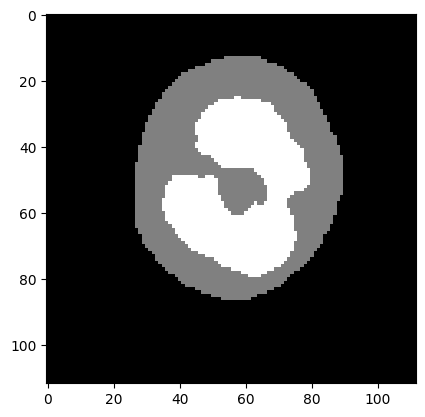

In [27]:
mask_path = cv2.imread(r"D:\work\WBC_Segmentation\WhileBloodCellClassification\data/RawData/Dataset 1/147.png",0)
plt.imshow(mask_path, cmap='gray')
plt.show()

In [28]:
mask = masks[49]
masks = masks.float()
mask

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])

In [29]:
print(torch.unique(masks))
for k in range(3):
    ratio = (masks == k).float().mean()
    print(k, ratio.item())

tensor([0., 1., 2.])
0 0.7724446058273315
1 0.12652282416820526
2 0.1010325625538826


In [56]:
idx = 76
image = images[idx]
mask_img = masks[idx]
image = image.unsqueeze(0)
print(image.shape)

torch.Size([1, 3, 256, 256])


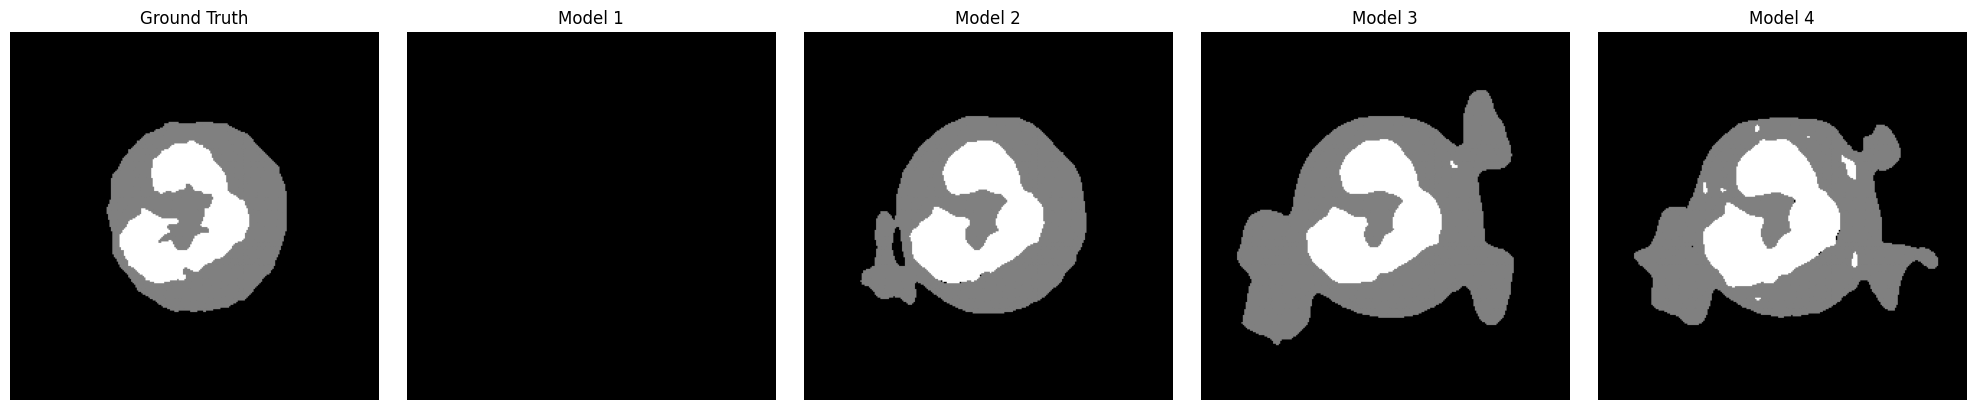

In [57]:
masks_img_1 = trained_model_1(image)[0]
masks_img_2 = trained_model_2(image)[0]
masks_img_3 = trained_model_3(image)[0]
masks_img_4 = trained_model_4(image)[0]

pred_1 = masks_img_1.squeeze(0)
pred_2 = masks_img_2.squeeze(0)
pred_3 = masks_img_3.squeeze(0)
pred_4 = masks_img_4.squeeze(0)

mask_1 = pred_1.argmax(dim=0)
mask_2 = pred_2.argmax(dim=0)
mask_3 = pred_3.argmax(dim=0)
mask_4 = pred_4.argmax(dim=0)

# ===== Ground truth (FIX ở đây) =====
mask_0 = mask_img   # (H, W), không cần argmax

# ===== Convert numpy =====
mask_np_0 = mask_0.cpu().numpy()
mask_np_1 = mask_1.cpu().numpy()
mask_np_2 = mask_2.cpu().numpy()
mask_np_3 = mask_3.cpu().numpy()
mask_np_4 = mask_4.cpu().numpy()

# ===== Scale =====
mask_vis_0 = (mask_np_0 * (255 // 2)).astype(np.uint8)
mask_vis_1 = (mask_np_1 * (255 // 2)).astype(np.uint8)
mask_vis_2 = (mask_np_2 * (255 // 2)).astype(np.uint8)
mask_vis_3 = (mask_np_3 * (255 // 2)).astype(np.uint8)
mask_vis_4 = (mask_np_4 * (255 // 2)).astype(np.uint8)

# ===== Plot =====
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Ground Truth
axes[0].imshow(mask_vis_0, cmap='gray')
axes[0].set_title("Ground Truth")
axes[0].axis('off')

# Models
axes[1].imshow(mask_vis_1, cmap='gray')
axes[1].set_title("Model 1")
axes[1].axis('off')

axes[2].imshow(mask_vis_2, cmap='gray')
axes[2].set_title("Model 2")
axes[2].axis('off')

axes[3].imshow(mask_vis_3, cmap='gray')
axes[3].set_title("Model 3")
axes[3].axis('off')

axes[4].imshow(mask_vis_4, cmap='gray')
axes[4].set_title("Model 4")
axes[4].axis('off')

plt.tight_layout()
plt.show()

In [32]:
img_path = r"D:\work\WBC_Segmentation\WhileBloodCellClassification\data/RawData\Dataset 1/001.bmp"
image = Image.open(img_path).convert("RGB")
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])
img_resized = transform(image).unsqueeze(0)  
pred = trained_model_20(img_resized)[0]
pred = pred.squeeze(0)
mask = pred.argmax(dim=0)
import numpy as np

mask_np = mask.cpu().numpy()

# scale về 0–255
mask_vis = (mask_np * (255 // 2)).astype(np.uint8)

plt.imshow(mask_vis, cmap='gray')
plt.show()


NameError: name 'trained_model_20' is not defined

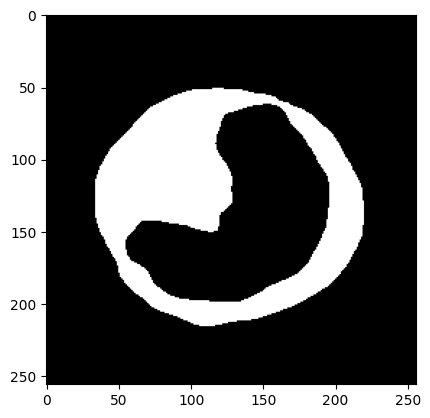

In [ ]:
masks_img = trained_model_3(image)[0]

pred = masks_img.squeeze(0)
mask = pred.argmax(dim=0)


import numpy as np

mask_np = mask.cpu().numpy()

# scale về 0–255
mask_vis = (mask_np * (255 // 2)).astype(np.uint8)

plt.imshow(mask_vis, cmap='gray')
plt.show()


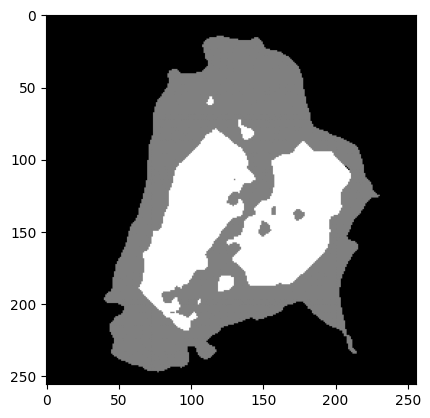

In [ ]:
masks_img = trained_model_15(image)[0]

pred = masks_img.squeeze(0)
mask = pred.argmax(dim=0)

import numpy as np

mask_np = mask.cpu().numpy()

# scale về 0–255
mask_vis = (mask_np * (255 // 2)).astype(np.uint8)

plt.imshow(mask_vis, cmap='gray')
plt.show()


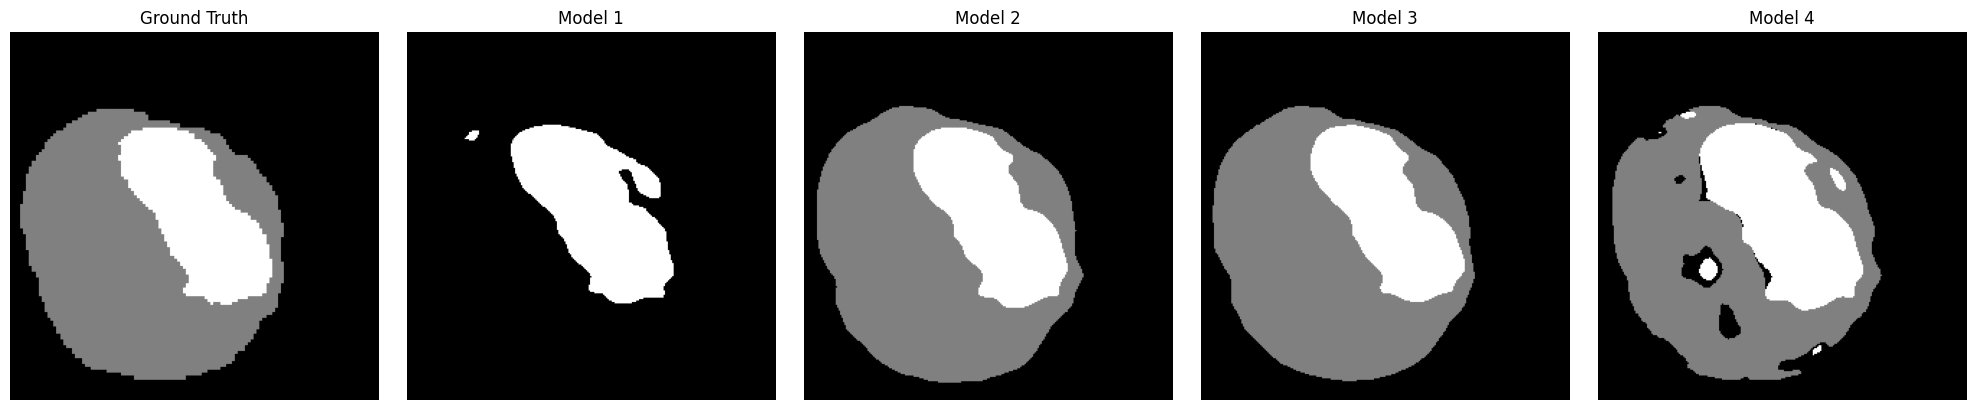

In [ ]:
masks_img_1 = trained_model_1(image)[0]
masks_img_2 = trained_model_2(image)[0]
masks_img_3 = trained_model_3(image)[0]
masks_img_4 = trained_model_4(image)[0]

pred_1 = masks_img_1.squeeze(0)
pred_2 = masks_img_2.squeeze(0)
pred_3 = masks_img_3.squeeze(0)
pred_4 = masks_img_4.squeeze(0)

mask_1 = pred_1.argmax(dim=0)
mask_2 = pred_2.argmax(dim=0)
mask_3 = pred_3.argmax(dim=0)
mask_4 = pred_4.argmax(dim=0)

# ===== Ground truth (FIX ở đây) =====
mask_0 = mask_img   # (H, W), không cần argmax

# ===== Convert numpy =====
mask_np_0 = mask_0.cpu().numpy()
mask_np_1 = mask_1.cpu().numpy()
mask_np_2 = mask_2.cpu().numpy()
mask_np_3 = mask_3.cpu().numpy()
mask_np_4 = mask_4.cpu().numpy()

# ===== Scale =====
mask_vis_0 = (mask_np_0 * (255 // 2)).astype(np.uint8)
mask_vis_1 = (mask_np_1 * (255 // 2)).astype(np.uint8)
mask_vis_2 = (mask_np_2 * (255 // 2)).astype(np.uint8)
mask_vis_3 = (mask_np_3 * (255 // 2)).astype(np.uint8)
mask_vis_4 = (mask_np_4 * (255 // 2)).astype(np.uint8)

# ===== Plot =====
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Ground Truth
axes[0].imshow(mask_vis_0, cmap='gray')
axes[0].set_title("Ground Truth")
axes[0].axis('off')

# Models
axes[1].imshow(mask_vis_1, cmap='gray')
axes[1].set_title("Model 1")
axes[1].axis('off')

axes[2].imshow(mask_vis_2, cmap='gray')
axes[2].set_title("Model 2")
axes[2].axis('off')

axes[3].imshow(mask_vis_3, cmap='gray')
axes[3].set_title("Model 3")
axes[3].axis('off')

axes[4].imshow(mask_vis_4, cmap='gray')
axes[4].set_title("Model 4")
axes[4].axis('off')

plt.tight_layout()
plt.show()

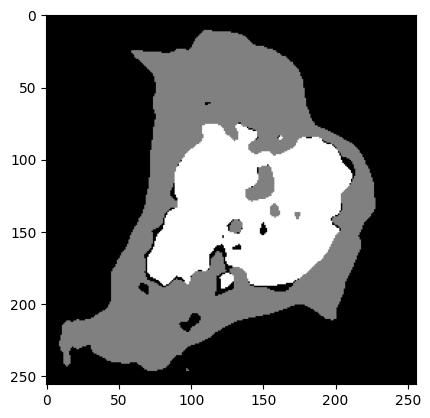

In [ ]:

masks_img = trained_model_25(image)[0]

pred = masks_img.squeeze(0)
mask = pred.argmax(dim=0)

import numpy as np

mask_np = mask.cpu().numpy()

# scale về 0–255
mask_vis = (mask_np * (255 // 2)).astype(np.uint8)

plt.imshow(mask_vis, cmap='gray')
plt.show()


In [ ]:
print(torch.unique(mask))
print(mask.mean(dim=(1,2)))

tensor([0, 1, 2])


RuntimeError: mean(): could not infer output dtype. Input dtype must be either a floating point or complex dtype. Got: Long

In [ ]:
LEARNING_RATE = 2e-4
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 1
NUM_WORKERS = 4
IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256
PIN_MEMORY = True
LOAD_MODEL = False
WEIGHT_DECAY = 5e-5
weight_cross_entropy = 2
weight_mask = 5
weight_rec = 1


In [ ]:

def save_checkpoint(state, filename="my_checkpoint.pth.tar"):
    print("=> Saving checkpoint")
    torch.save(state, filename)

def load_checkpoint(checkpoint, model):
    print("=> Loading checkpoint")
    model.load_state_dict(checkpoint["state_dict"])

def check_accuracy(loader,model,device="cuda"):
    num_correct = 0
    num_pixels = 0
    dice_score = 0
    model.eval()
    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)
            y = y.to(device)
            preds = torch.sigmoid(model(x))
            num_correct += (preds == y).sum()
            num_pixels += torch.numel(preds)
            dice_score += (2 * (preds * y).sum()) / ((preds + y).sum() + 1e-8)
    print(f"Got {num_correct}/{num_pixels} with acc {num_correct/num_pixels*100:.2f}")
    print(f"Dice score: {dice_score/len(loader)}")
    model.train()
    
def get_optimizer(model, reconstruction, learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY):

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(reconstruction.parameters()),
        lr=learning_rate,
        weight_decay=float(weight_decay),
        betas=(0.9, 0.999)
    )
    return optimizer

def get_scaler():

    scaler = torch.cuda.amp.GradScaler()
    return scaler

In [ ]:
from tqdm import tqdm

In [ ]:
def training_fn(loader, model, optimizer, CrossEntropyLoss,DICELoss,BCELoss, ReconstructionLoss, scaler):
    loop = tqdm(loader)
    
    for batch_idx in loop:
        images = batch["image"]
        masks = batch["mask"]
        binarys = batch["binary"]
        images = images.to(device=DEVICE)
        masks = masks.float().to(device=DEVICE)
        masks_long = masks.long().to(device=DEVICE)
        binarys = binarys.float().to(device=DEVICE)

        # forward
        with torch.cuda.amp.autocast():
            predictions, encoded_features, query_features = model(images)
            CrossEntropy = CrossEntropyLoss(predictions, masks_long)
            mask_loss = 0
            K = predictions.shape[1]
            for k in range(K):
                pred_binary  = predictions[:, k:k+1, :, :]
                target_binary = (masks == k).float()
                dice = DICELoss(pred_binary, target_binary.long())
                bce = BCELoss(pred_binary, target_binary.unsqueeze(1))
                mask_loss += bce + dice
            Reconstruction = ReconstructionLoss(encoded_features, query_features)
            loss = weight_cross_entropy * CrossEntropy + weight_mask * mask_loss + weight_rec * Reconstruction

        # backward
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # update tqdm loop        
        loop.set_postfix(loss=loss.item())


In [ ]:
os.getcwd()

'd:\\work\\WBC_Segmentation'

In [ ]:
from WhiteBloodCellClassification.DomainAdaptation.DA_module import DomainAdaptationModule
from WhiteBloodCellClassification.models.losses import DiceLoss, BCELoss, ReconstructionLoss, CLSLoss

In [ ]:
model = DomainAdaptationModule().to(DEVICE)
CrossEntropyLoss = CLSLoss()
diceLoss = DiceLoss()
bceLoss = BCELoss()
reconstructionLoss = ReconstructionLoss()
optimizer = get_optimizer(model)
scaler = get_scaler()
training_fn(loader=dataloader, model=model, optimizer=optimizer, CrossEntropyLoss=CrossEntropyLoss, DICELoss=diceLoss, BCELoss=bceLoss, ReconstructionLoss=reconstructionLoss, scaler=scaler)

TypeError: get_optimizer() missing 1 required positional argument: 'reconstruction'

In [ ]:
model = DomainAdaptationModule().to(DEVICE)
for name, param in model.named_parameters():
    print(name, param.shape)

In [ ]:
class ReconstructionLoss(nn.Module):
    def __init__(self, encoder_dim=2048, query_dim=256, use_c3=True):
        super().__init__()
        self.use_c3 = use_c3
        
        self.reconstruction_mlp = nn.Sequential(
            nn.Linear(query_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(512, encoder_dim),
            nn.LayerNorm(encoder_dim)  # Thêm LayerNorm để ổn định
        )
        
        if use_c3:
            self.feature_proj = nn.Linear(1024, encoder_dim)
        else:
            self.feature_proj = None
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.reconstruction_mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)  # Giảm gain
                nn.init.constant_(m.bias, 0.0)
        if self.feature_proj is not None:
            nn.init.xavier_uniform_(self.feature_proj.weight, gain=0.5)
            nn.init.constant_(self.feature_proj.bias, 0.0)
    
    def forward(self, encoder_features, query_features):
        # Lấy feature
        if self.use_c3:
            target_feature = encoder_features[2]  # c3: [B, 1024, H, W]
            g_i = target_feature.mean(dim=[2, 3])  # [B, 1024]
            g_i = self.feature_proj(g_i)  # [B, 2048]
        else:
            target_feature = encoder_features[3]  # c4: [B, 2048, H, W]
            g_i = target_feature.mean(dim=[2, 3])  # [B, 2048]
        
        # QUAN TRỌNG: Detach và không normalize ngay
        g_i = g_i.detach()
        
        # Lấy query 0
        g_hat = query_features[:, 0, :]  # [B, 256]
        g_hat = self.reconstruction_mlp(g_hat)  # [B, 2048]
        
        # ===== CÁCH TÍNH LOSS MỚI =====
        # Không normalize trước, tính loss trực tiếp
        
        # Option 1: MSE trên raw features (có scale)
        loss_raw = F.mse_loss(g_hat, g_i)
        
        # Option 2: Cosine similarity loss (chỉ quan tâm hướng)
        cos_sim = F.cosine_similarity(g_hat, g_i, dim=1).mean()
        loss_cos = 1 - cos_sim
        
        # Option 3: MSE trên normalized features (đúng công thức)
        g_i_norm = F.normalize(g_i, p=2, dim=1)
        g_hat_norm = F.normalize(g_hat, p=2, dim=1)
        loss_norm_mse = F.mse_loss(g_hat_norm, g_i_norm)
        
        # Debug
        with torch.no_grad():
            print(f"Loss raw (MSE): {loss_raw.item():.6f}")
            print(f"Loss cos (1 - cos): {loss_cos.item():.6f}")
            print(f"Loss norm MSE: {loss_norm_mse.item():.6f}")
            
            # Kiểm tra cosine similarity
            cos_sim_value = F.cosine_similarity(g_hat, g_i, dim=1).mean()
            print(f"Cosine similarity (raw): {cos_sim_value:.4f}")
            
            cos_sim_norm = F.cosine_similarity(g_i_norm, g_hat_norm, dim=1).mean()
            print(f"Cosine similarity (norm): {cos_sim_norm:.4f}")
        
        # Sử dụng loss_cos vì nó ổn định hơn
        return loss_cos * 0.5  # Weight 0.5

In [ ]:
# Test code
if __name__ == "__main__":
    # Tạo dummy features
    B, C, H, W = 2, 3, 256, 256
    
    # Giả lập encoder_features
    encoder_features = [
        torch.randn(B, 256, H//4, W//4),   # c1
        torch.randn(B, 512, H//8, W//8),   # c2
        torch.randn(B, 1024, H//16, W//16), # c3
        torch.randn(B, 2048, H//32, W//32)  # c4
    ]
    
    # Giả lập query_features
    num_queries = 32
    query_dim = 256
    query_features = torch.randn(B, num_queries, query_dim)
    
    # Test ReconstructionLoss
    rec_loss = ReconstructionLoss(encoder_dim=512, query_dim=256, use_c3=True)
    loss = rec_loss(encoder_features, query_features)
    
    print(f"\nFinal loss: {loss.item():.6f}")

Loss raw (MSE): 1.002888
Loss cos (1 - cos): 1.027537
Loss norm MSE: 0.004014
Cosine similarity (raw): -0.0275
Cosine similarity (norm): -0.0275

Final loss: 0.513768
